# Kmeans


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, 
                             davies_bouldin_score, adjusted_rand_score, 
                             normalized_mutual_info_score, jaccard_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score, jaccard_score
from sklearn.manifold import TSNE
from matplotlib.ticker import FixedLocator

def find_elbow_k(k_range, sse):
    """Automatiškai randa alkūnės tašką (didžiausią kreivės lūžį)."""
    p1 = np.array([k_range[0], sse[0]])
    p2 = np.array([k_range[-1], sse[-1]])
    distances = []
    for i in range(len(k_range)):
        p0 = np.array([k_range[i], sse[i]])
        dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)
        distances.append(dist)
    return k_range[np.argmax(distances)]

def draw_styled_clusters(ax, data, labels, title, is_tsne=False):
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # Pridedame ašis projekcijai
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    for i, label in enumerate(unique_labels):
        points = data[labels == label]
        color = colors[i]
        ax.scatter(points[:, 0], points[:, 1], color=color, s=15, alpha=0.5)

        if len(data) < 300:
            indices = np.where(labels == label)[0]
            for idx, pt in zip(indices, points):
                ax.text(pt[0], pt[1], str(idx), fontsize=7, color=color)

        if len(points) > 2:
            mean = np.mean(points, axis=0)
            try:
                cov = np.cov(points, rowvar=False)
                vals, vecs = np.linalg.eigh(cov)
                order = vals.argsort()[::-1]
                vals, vecs = vals[order], vecs[:, order]
                theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
                width, height = 2 * 2 * np.sqrt(np.abs(vals))

                ell = patches.Ellipse(
                    xy=mean,
                    width=width,
                    height=height,
                    angle=theta,
                    edgecolor=color,
                    facecolor='none',
                    linewidth=1.5,
                    hatch='////',
                    alpha=0.2
                )
                ax.add_patch(ell)
                ax.text(mean[0], mean[1], f"K{label}", fontsize=12, fontweight='bold', color='black', 
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
            except:
                pass # Jei kovariacija neskaičiuojama (pvz. kolinearūs taškai)

def perform_full_analysis(data, labels_true, labels_true_str, dim_name, viz_2d=None):
    print(f"\n{'-'*15} ANALIZĖ: {dim_name} {'-'*15}")

    k_range = range(2, 21)
    sse = []
    sil_scores = []
    results_by_k = {}

    # Klasterizacija vykdoma 'data' erdvėje (gali būti 2D, 25D, 50D ir t.t.)
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        l_pred = km.fit_predict(data)
        sse.append(km.inertia_)
        sil_scores.append(silhouette_score(data, l_pred))
        
        results_by_k[k] = {
            "sil": sil_scores[-1],
            "ch": calinski_harabasz_score(data, l_pred),
            "db": davies_bouldin_score(data, l_pred),
            "ari": adjusted_rand_score(labels_true, l_pred),
            "nmi": normalized_mutual_info_score(labels_true, l_pred),
            "jac": jaccard_score(labels_true, l_pred, average="macro"),
        }

    k_silhouette = k_range[np.argmax(sil_scores)]
    k_elbow = find_elbow_k(list(k_range), sse)

    # Nustatome vizualizacijos koordinates
    # Jei viz_2d neperduotas, skaičiuojame jį iš 'data'
    if viz_2d is None:
        if data.shape[1] == 2:
            viz_2d = data
        else:
            print(f"Generuojama t-SNE projekcija vizualizacijai ({dim_name})...")
            viz_2d = TSNE(n_components=2, random_state=42).fit_transform(data)

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 6))

    # 1. Elbow
    ax1.plot(k_range, sse, "bo-", markersize=4)
    ax1.set_title("Alkūnės metodas")
    ax1.set_xlabel("Klasterių skaičius")
    ax1.set_ylabel("Inercija (WCBRC)")
    ax1.axvline(k_elbow, color="orange", ls="--", label=f"Alkūnė k={k_elbow}")
    ax1.xaxis.set_major_locator(FixedLocator(list(k_range)))
    ax1.grid(True, alpha=0.3)

    # 2. Silhouette
    ax2.plot(k_range, sil_scores, "ro-", markersize=4)
    ax2.set_title("Silhouette koeficientas")
    ax2.set_xlabel("Klasterių skaičius (k)")
    ax2.set_ylabel("Vidutinis Siluetas")
    ax2.axvline(k_silhouette, color="green", ls="--", label=f"Optimumas k={k_silhouette}")
    ax2.xaxis.set_major_locator(FixedLocator(list(k_range)))
    ax2.grid(True, alpha=0.3)

    # 3. K-Means (naudojant perduotą viz_2d)
    final_labels_opt = KMeans(n_clusters=k_silhouette, random_state=42, n_init=10).fit_predict(data)
    draw_styled_clusters(ax3, viz_2d, final_labels_opt, f"K-Means (k={k_silhouette})", is_tsne=True)

    # 4. Tikrosios klasės (naudojant perduotą viz_2d)
    unique_types = sorted(np.unique(labels_true_str)) 
    tab10_colors = plt.cm.tab10.colors 
    
    ax4.set_title(f"Tikrosios klasės ({dim_name})", fontsize=12, fontweight='bold')
    for i, ship_type in enumerate(unique_types):
        mask = (labels_true_str == ship_type)
        ax4.scatter(viz_2d[mask, 0], viz_2d[mask, 1], label=ship_type, s=30, alpha=0.7, 
                    color=tab10_colors[i % 10], edgecolors='white', linewidth=0.5)
    
    ax4.set_xlabel("t-SNE 1")
    ax4.set_ylabel("t-SNE 2")
    ax4.legend(title="labels", loc='upper left', frameon=True, fontsize=10)

    plt.tight_layout()
    plt.show()

    res_opt = results_by_k[k_silhouette]
    return [{"Dimensija": f"{dim_name} (Opt)", "K": k_silhouette, "Metodas": "Silhouette", **res_opt}]



In [13]:
# --- 3. PAGRINDINĖ ANALIZĖ ---
dist_mat = np.load('dist_mat.npy')
original_data = np.load('original_data.npy')
labels_true_str = np.load('ship-types.npy')
le = LabelEncoder()
labels_true = le.fit_transform(labels_true_str)

# Empyrinis K
n_samples = dist_mat.shape[0]
empiric_k = int(np.sqrt(n_samples / 2))

# Paleidimas
final_summary = []

num_classes = len(np.unique(labels_true_str))

print(f"Originalių klasių (laivų tipų) skaičius: {num_classes}")

Originalių klasių (laivų tipų) skaičius: 5



--------------- ANALIZĖ: Originali ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_20069/4098599928.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


Generuojama t-SNE projekcija vizualizacijai (Originali)...


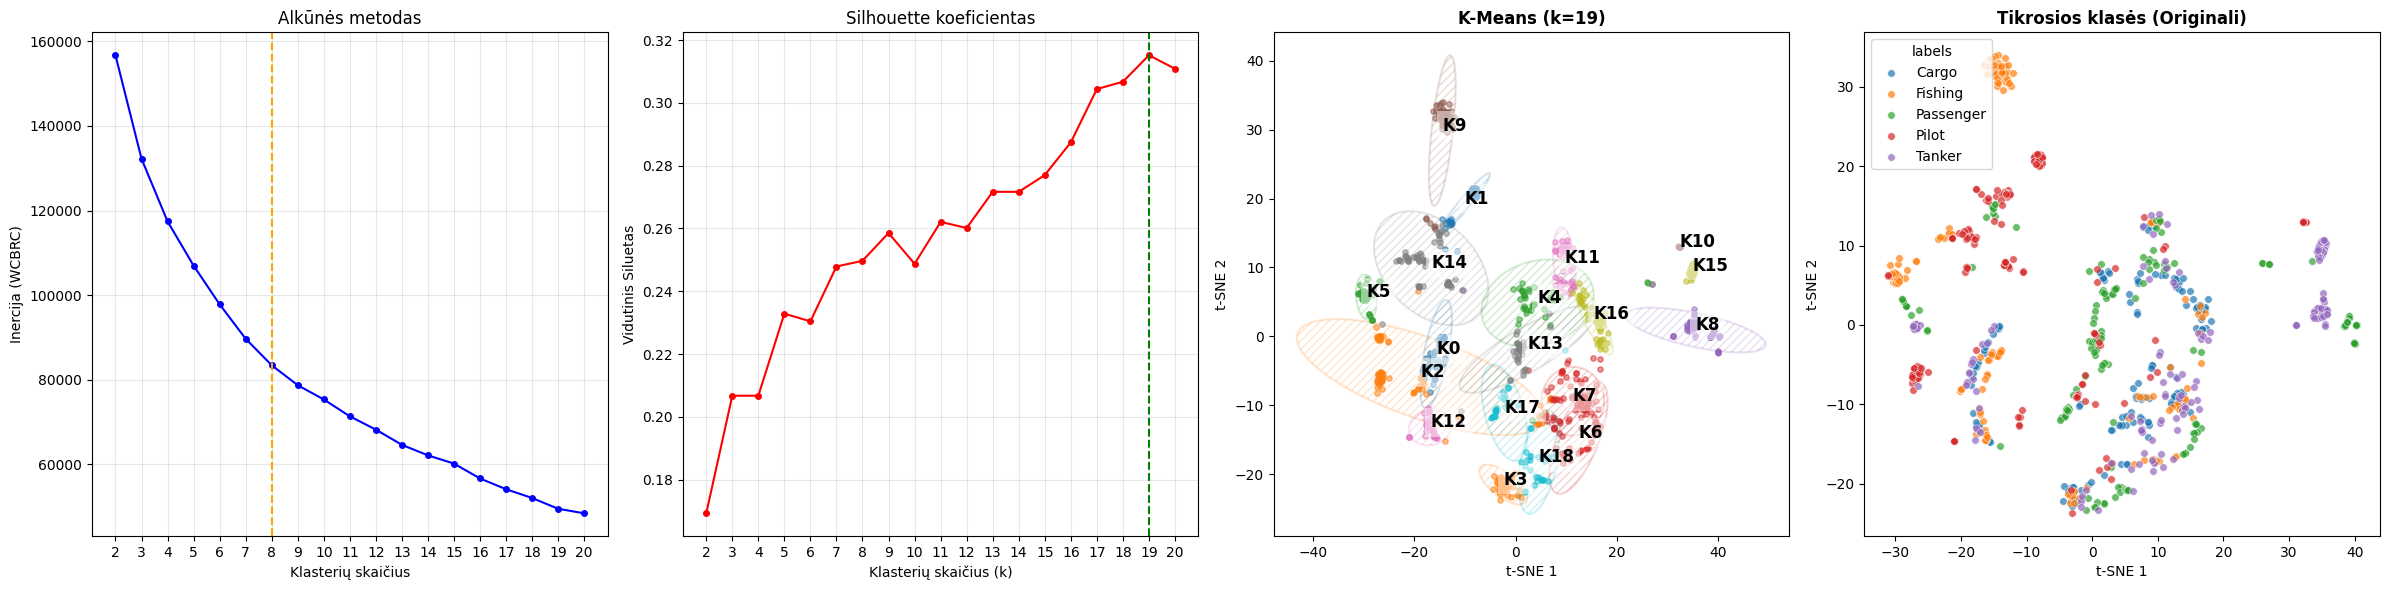

In [14]:
original_data_scaled = StandardScaler().fit_transform(original_data.reshape(n_samples, -1))

final_summary.append(perform_full_analysis(original_data_scaled, labels_true, labels_true_str, "Originali"))


--------------- ANALIZĖ: 2D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_20069/4098599928.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


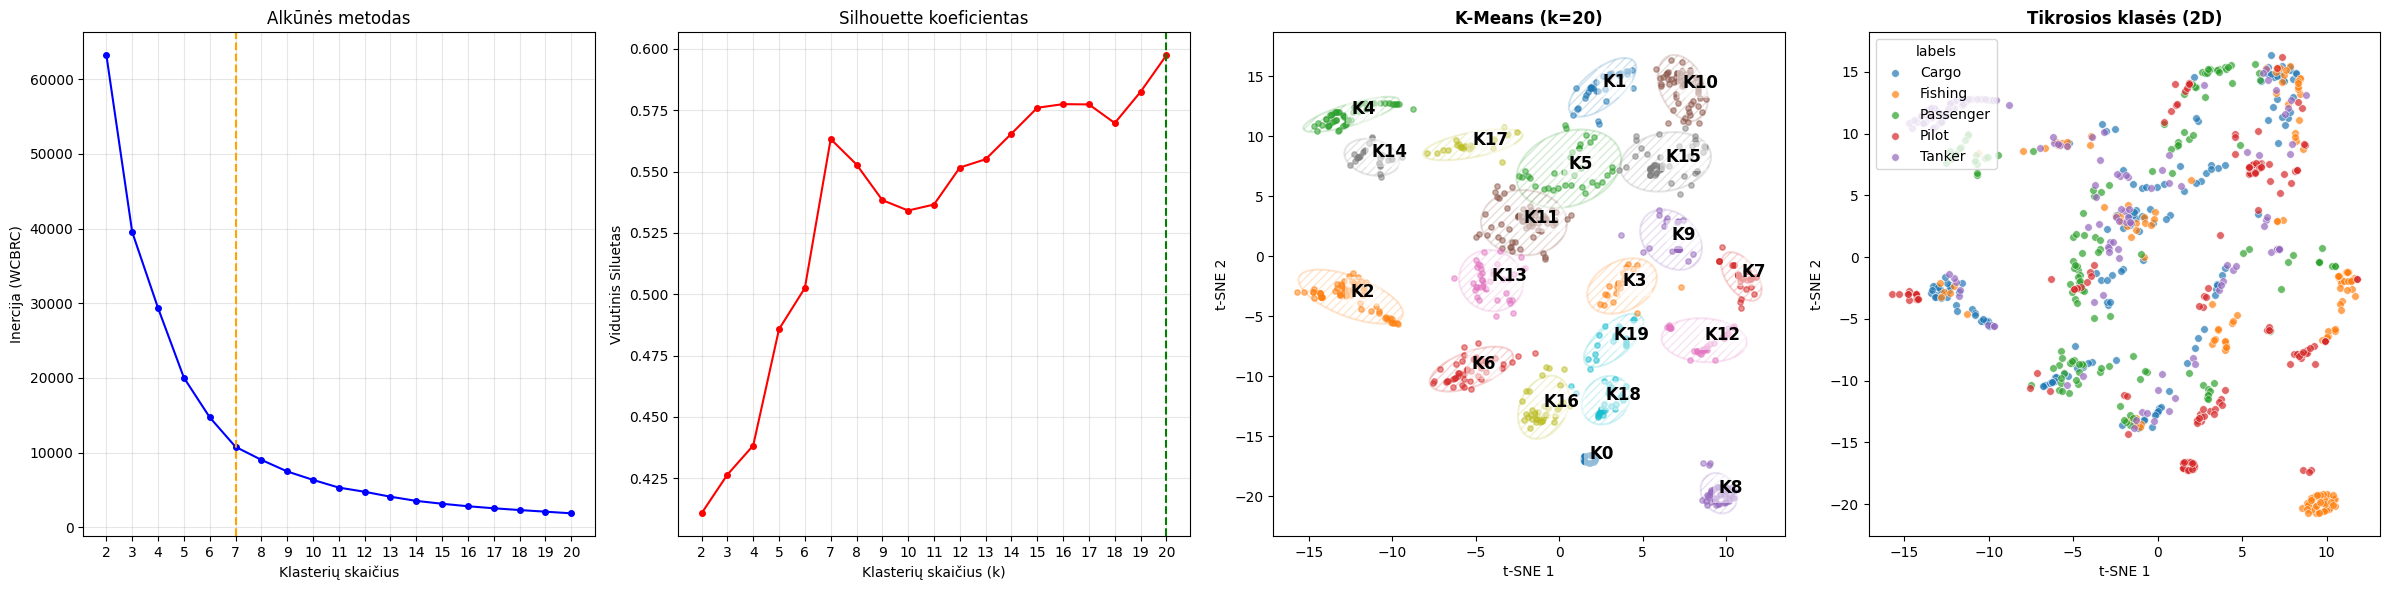


--------------- ANALIZĖ: 25D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_20069/4098599928.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


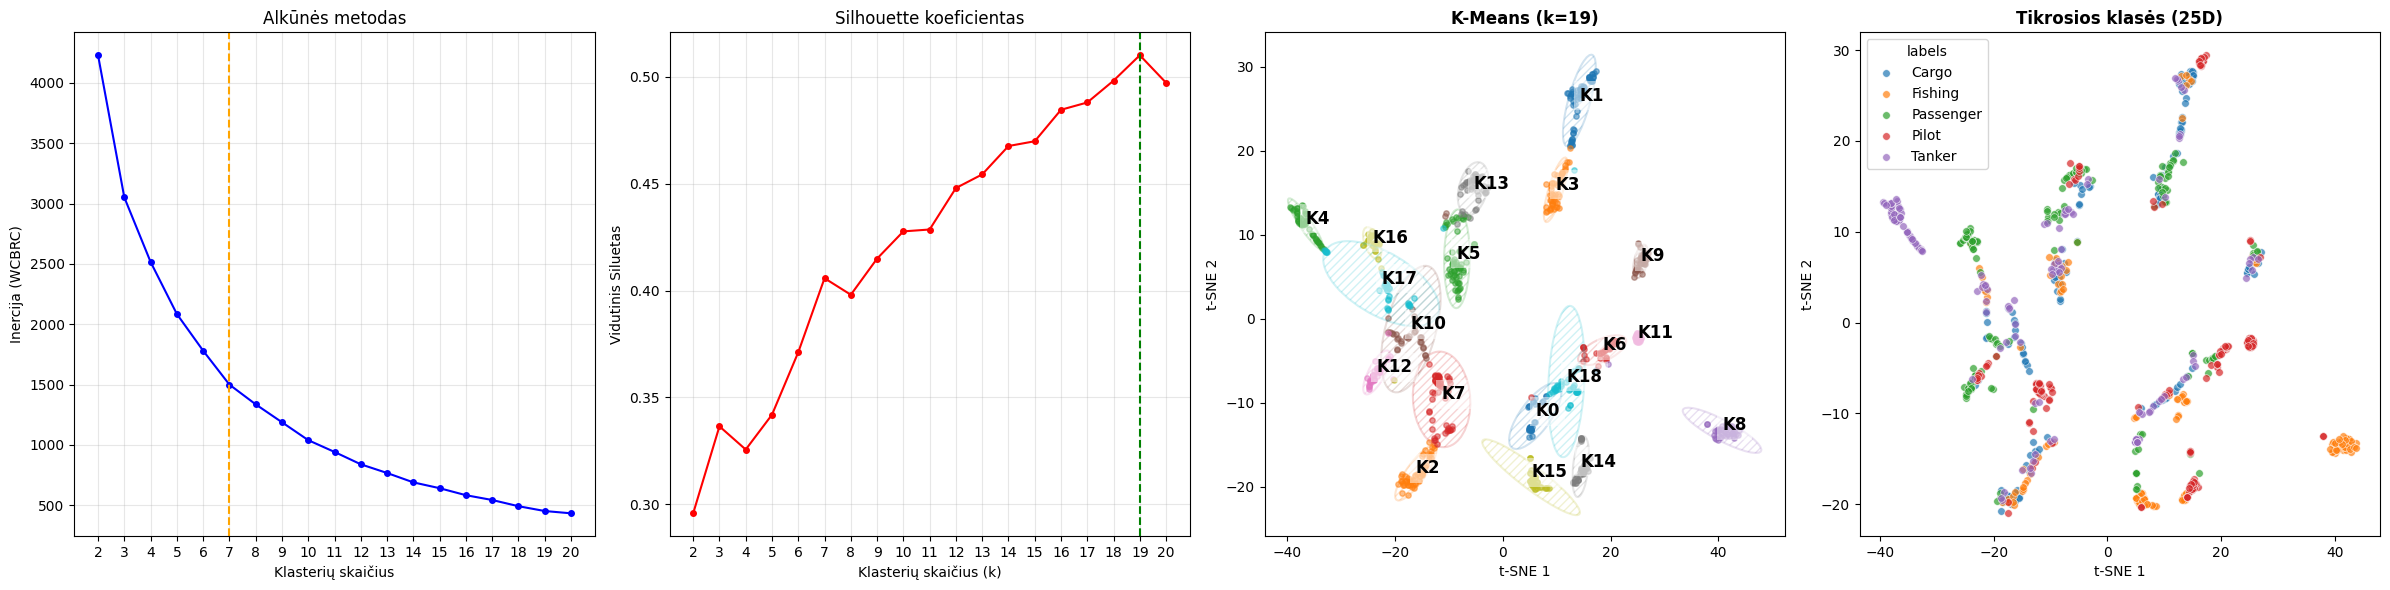


--------------- ANALIZĖ: 50D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_20069/4098599928.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


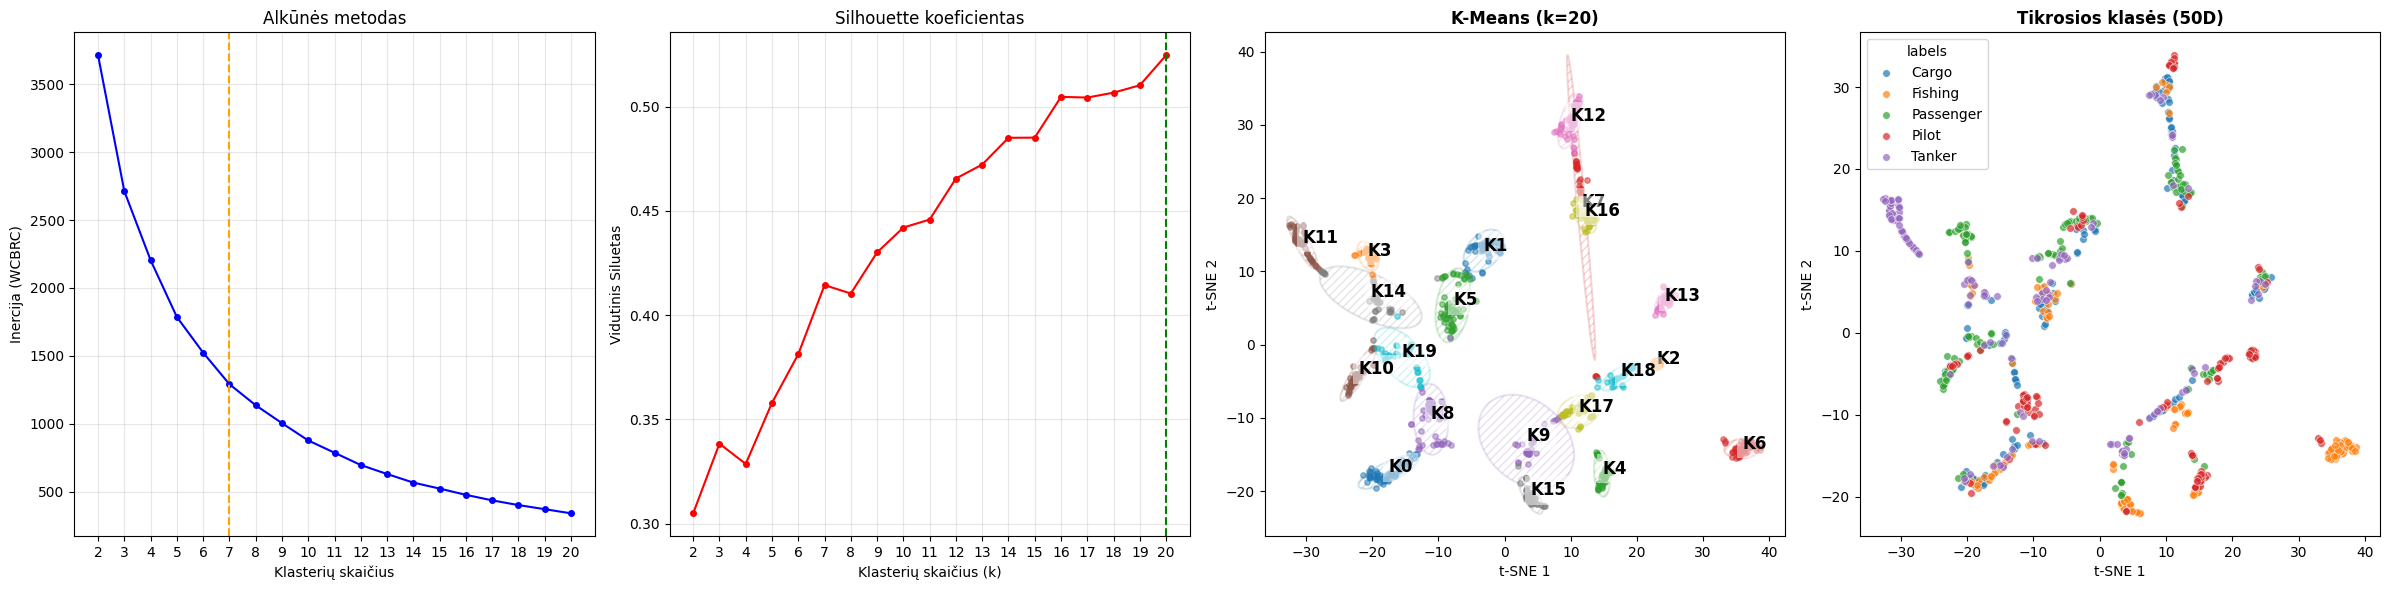

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:61: RuntimeWarning: overflow encountered in cast
  distances = distances.astype(np.float32, copy=False)



--------------- ANALIZĖ: 100D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_20069/4098599928.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


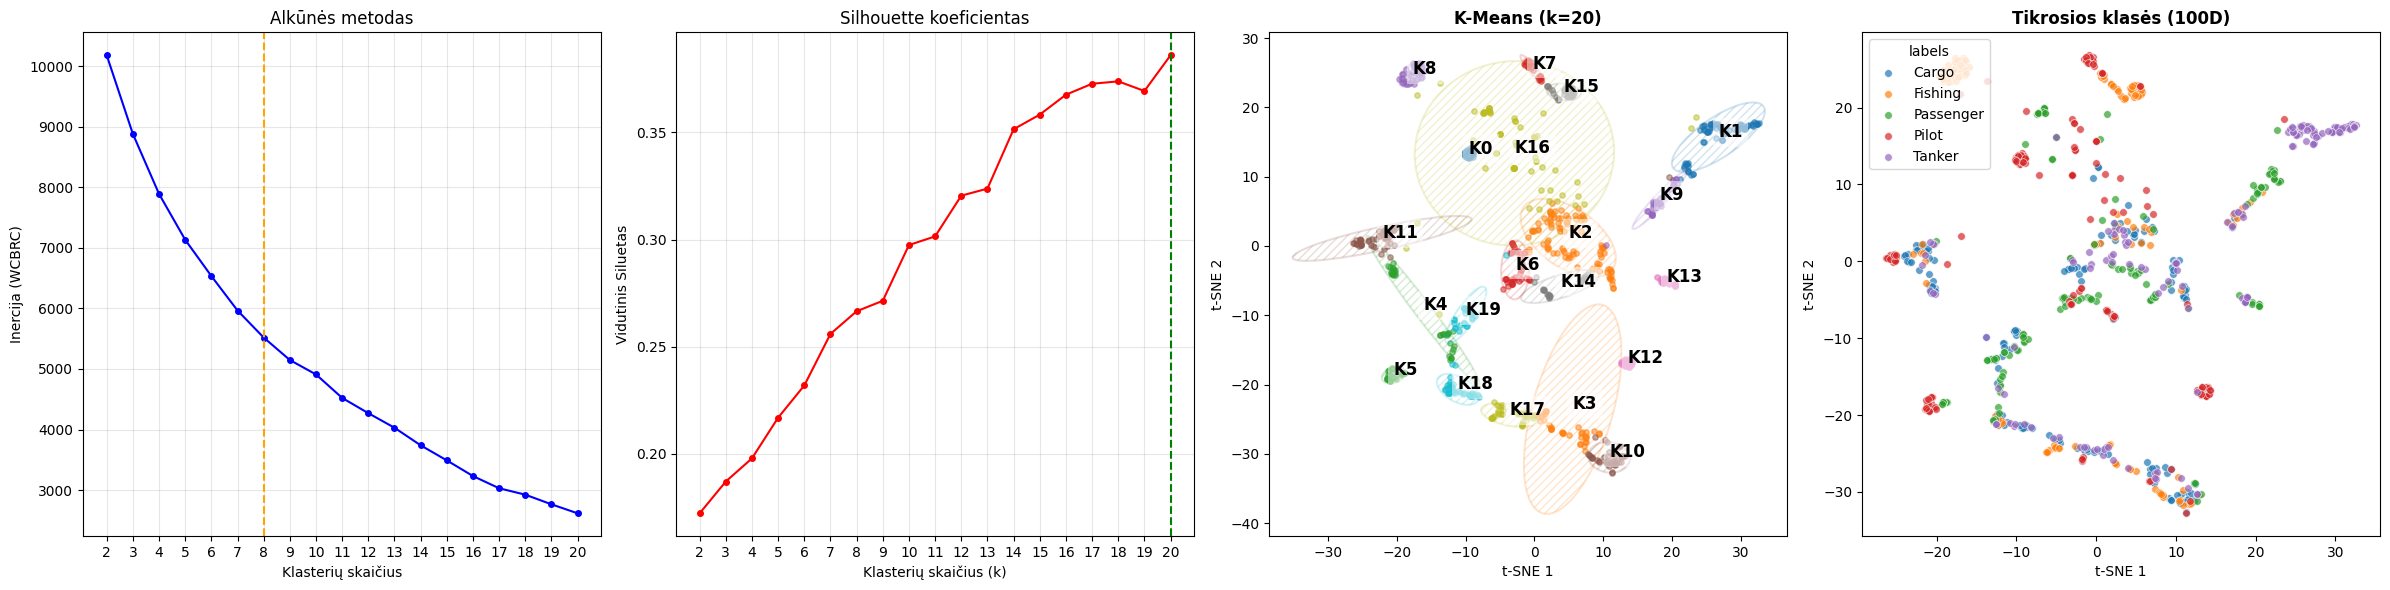

In [ ]:
viz_base = TSNE(n_components=2, perplexity=5, metric='precomputed', method='exact', init="random", random_state=42).fit_transform(dist_mat)

for d in [2, 25, 50, 100]:
    # Sukuriame d-dimensinį embeddingą (tai bus duomenys klasterizacijai)
    emb_d = TSNE(n_components=d, perplexity=5, metric='precomputed', method='exact', init="random", random_state=42).fit_transform(dist_mat)
    
    # Jei d > 2, vizualizacijai sukuriamas 2D vaizdas būtent iš TO embeddingo
    # Tai parodys, kaip 25D struktūra atrodo suspausta į 2D
    if d == 2:
        v2d = emb_d
    else:
        v2d = TSNE(n_components=2, random_state=42).fit_transform(emb_d)
    
    # Kviečiame analizę perduodami abu: emb_d (skaičiavimams) ir v2d (piešimui)
    final_summary.append(perform_full_analysis(emb_d, labels_true, labels_true_str, f"{d}D", viz_2d=v2d))

In [16]:

# --- 4. GALUTINIS PALYGINIMAS ---
df_final = pd.DataFrame(final_summary)
print("\n" + "="*100)
print("VISŲ DIMENSIJŲ IR OPTIMALIŲ K PALYGINIMAS")
print("="*100)
print(df_final.to_string(index=False))


VISŲ DIMENSIJŲ IR OPTIMALIŲ K PALYGINIMAS
                                                                                                                                                                                                                                    0
{'Dimensija': 'Originali (Opt)', 'K': 19, 'Metodas': 'Silhouette', 'sil': 0.3151729471281904, 'ch': 113.16356399489432, 'db': 1.224901664756759, 'ari': 0.11209968422794811, 'nmi': 0.27714661616070274, 'jac': 0.006672923471062306}
        {'Dimensija': '2D (Opt)', 'K': 20, 'Metodas': 'Silhouette', 'sil': 0.5973671674728394, 'ch': 2392.25341796875, 'db': 0.5441406459154586, 'ari': 0.12769434295308488, 'nmi': 0.29188700261796313, 'jac': 0.019848484848484848}
          {'Dimensija': '25D (Opt)', 'K': 19, 'Metodas': 'Silhouette', 'sil': 0.5101362466812134, 'ch': 522.0615844726562, 'db': 0.730599394168661, 'ari': 0.12242589671152004, 'nmi': 0.287928344602363, 'jac': 0.02061083689846639}
       {'Dimensija': '50D (Opt)', 'K'

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:61: RuntimeWarning: overflow encountered in cast
  distances = distances.astype(np.float32, copy=False)



--------------- ANALIZĖ IR STABILUMAS: 100D t-SNE ---------------
Vykdoma 10 stabilumo iteracijų (k=20)...


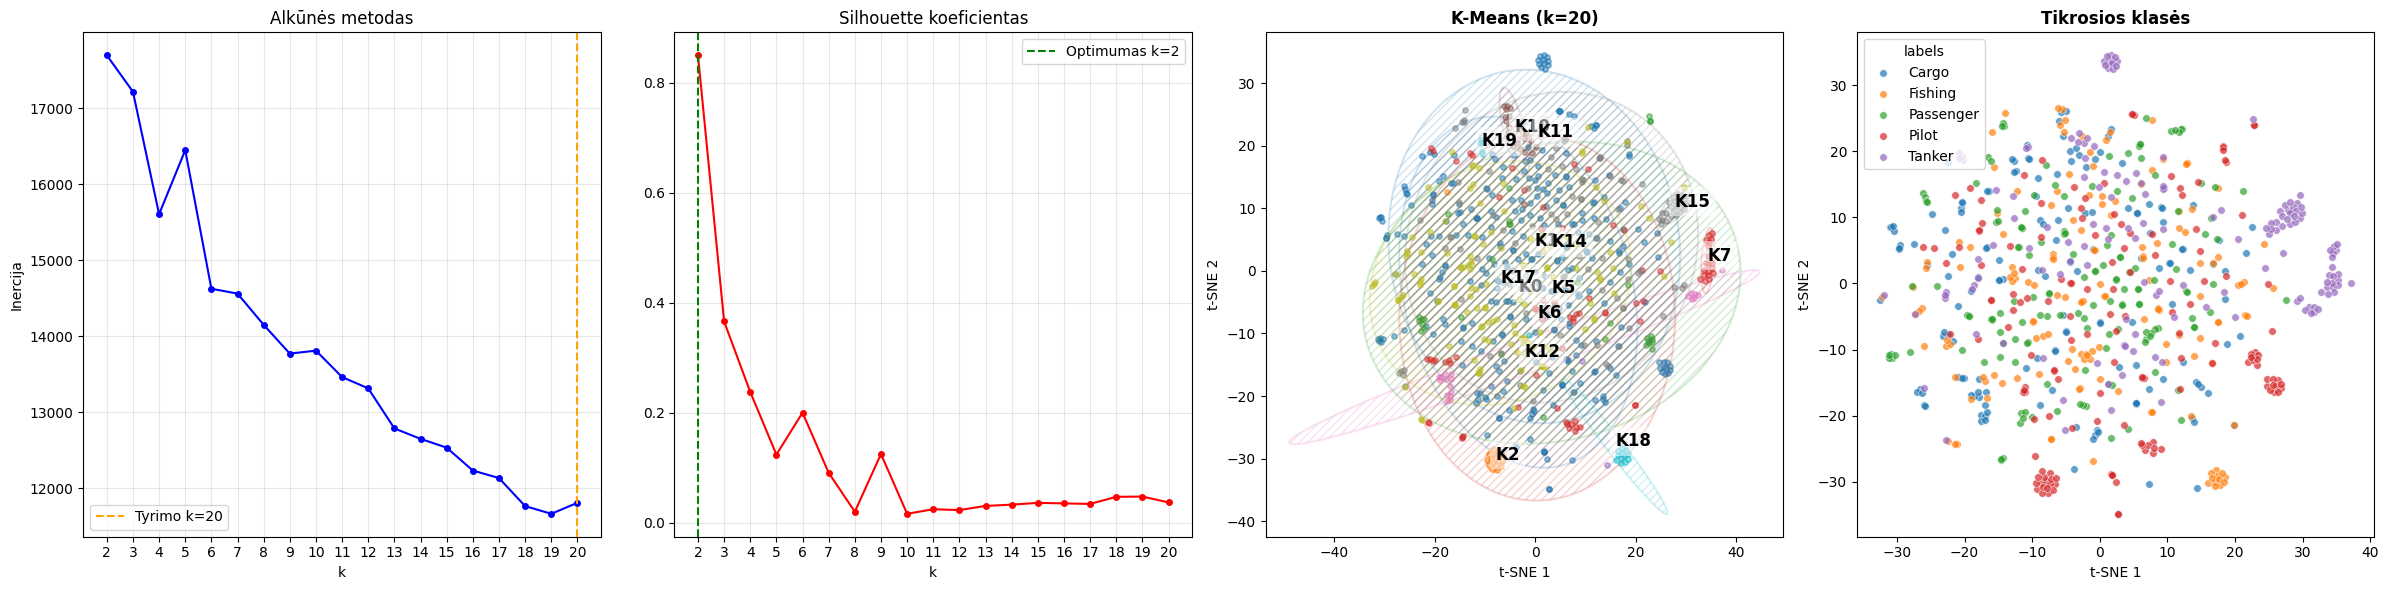


STABILUMO REZULTATAI (Vidurkis ± SD):
ARI:     0.0270 ± 0.0040
NMI:     0.1400 ± 0.0119
Jaccard: nan ± nan


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/

In [17]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, jaccard_score

def perform_stability_analysis(data_nd, viz_2d, labels_true, labels_true_str, dim_name, n_iter=10, sample_pct=0.8, k_fixed=19):
    print(f"\n{'-'*15} ANALIZĖ IR STABILUMAS: {dim_name} {'-'*15}")
    
    # --- 1. STANDARTINĖ ANALIZĖ (Kreivės) ---
    k_range = range(2, 21)
    sse = []
    sil_scores = []
    
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        l_pred = km.fit_predict(data_nd)
        sse.append(km.inertia_)
        sil_scores.append(silhouette_score(data_nd, l_pred))

    k_sil_opt = k_range[np.argmax(sil_scores)]

    # --- 2. STABILUMO SKAIČIAVIMAS (N-iteracijų) ---
    print(f"Vykdoma {n_iter} stabilumo iteracijų (k={k_fixed})...")
    all_results = []
    n_samples = data_nd.shape[0]

    for i in range(n_iter):
        # Atsitiktinė imtis (80%)
        indices = np.random.choice(range(n_samples), size=int(n_samples * sample_pct), replace=False)
        subset_data = data_nd[indices]
        
        # Klasterizuojame (naudojame i kaip random_state, kad rezultatai skirtųsi)
        km = KMeans(n_clusters=k_fixed, n_init=10, random_state=i)
        labels = km.fit_predict(subset_data)
        all_results.append((set(indices), dict(zip(indices, labels))))

    stability_ari, stability_nmi, stability_jac = [], [], []
    pairs = list(itertools.combinations(range(n_iter), 2))

# We don't need to compare y1 to y2. We need to compare y_pred to labels_true!
    for idx_set, lab_dict in all_results:
        # Get the true labels for this specific 80% subset
        y_true_subset = [labels_true[idx] for idx in idx_set]
        # Get the KMeans predictions for this subset
        y_pred_subset = [lab_dict[idx] for idx in idx_set]
        
        stability_ari.append(adjusted_rand_score(y_true_subset, y_pred_subset))
        stability_nmi.append(normalized_mutual_info_score(y_true_subset, y_pred_subset))


    # for i, j in pairs:
    #     idx1, lab_dict1 = all_results[i]
    #     idx2, lab_dict2 = all_results[j]
        
    #     # Randame bendrus taškus tarp dviejų skirtingų imčių
    #     common = list(idx1.intersection(idx2))
    #     if len(common) > 0:
    #         y1 = [lab_dict1[idx] for idx in common]
    #         y2 = [lab_dict2[idx] for idx in common]
            
    #         stability_ari.append(adjusted_rand_score(y1, y2))
    #         stability_nmi.append(normalized_mutual_info_score(y1, y2))
    #         stability_jac.append(jaccard_score(y1, y2, average='macro'))

    # --- 3. VIZUALIZACIJA (1x4) ---
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 6))

    # 1. Elbow
    ax1.plot(k_range, sse, "bo-", markersize=4)
    ax1.set_title("Alkūnės metodas")
    ax1.set_xlabel("k")
    ax1.set_ylabel("Inercija")
    ax1.axvline(k_fixed, color="orange", ls="--", label=f"Tyrimo k={k_fixed}")
    ax1.xaxis.set_major_locator(FixedLocator(list(k_range)))
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # 2. Silhouette
    ax2.plot(k_range, sil_scores, "ro-", markersize=4)
    ax2.set_title("Silhouette koeficientas")
    ax2.set_xlabel("k")
    ax2.axvline(k_sil_opt, color="green", ls="--", label=f"Optimumas k={k_sil_opt}")
    ax2.xaxis.set_major_locator(FixedLocator(list(k_range)))
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # 3. K-Means (su fiksuotu K)
    final_km = KMeans(n_clusters=k_fixed, n_init=10, random_state=42)
    final_labels = final_km.fit_predict(data_nd)
    draw_styled_clusters(ax3, viz_2d, final_labels, f"K-Means (k={k_fixed})", is_tsne=True)

    # 4. Tikrosios klasės (Ship Types)
    unique_types = sorted(np.unique(labels_true_str)) 
    tab10_colors = plt.cm.tab10.colors 
    ax4.set_title("Tikrosios klasės", fontsize=12, fontweight='bold')
    for i, ship_type in enumerate(unique_types):
        mask = (labels_true_str == ship_type)
        ax4.scatter(viz_2d[mask, 0], viz_2d[mask, 1], label=ship_type, s=30, alpha=0.7, 
                    color=tab10_colors[i % 10], edgecolors='white', linewidth=0.5)
    ax4.set_xlabel("t-SNE 1")
    ax4.set_ylabel("t-SNE 2")
    ax4.legend(title="labels", loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()

    # --- 4. REZULTATŲ SPAUSDINIMAS ---
    print("\nSTABILUMO REZULTATAI (Vidurkis ± SD):")
    print(f"ARI:     {np.mean(stability_ari):.4f} ± {np.std(stability_ari):.4f}")
    print(f"NMI:     {np.mean(stability_nmi):.4f} ± {np.std(stability_nmi):.4f}")
    print(f"Jaccard: {np.mean(stability_jac):.4f} ± {np.std(stability_jac):.4f}")

    return {
        "Dimensija": dim_name,
        "K": k_fixed,
        "Stab_ARI": np.mean(stability_ari),
        "Stab_NMI": np.mean(stability_nmi),
        "Stab_Jaccard": np.mean(stability_jac),
        "Silhouette": sil_scores[k_range.index(k_fixed)]
    }

# --- PALEIDIMO PAVYZDYS ---

# # 1. Sukuriamas 50D embedding'as klasterizacijai
emb_100d = TSNE(n_components=100, perplexity=5, metric='precomputed', method='exact',init="random", random_state=42).fit_transform(dist_mat)

# # 2. Sukuriamas 2D vaizdas vizualizacijai (kad matytume 50D struktūrą plokštumoje)
viz_2d = TSNE(n_components=2, random_state=42).fit_transform(emb_100d)

# 3. Analizė
results = perform_stability_analysis(
    data_nd=emb_100d, 
    viz_2d=viz_2d, 
    labels_true=labels_true, 
    labels_true_str=labels_true_str, 
    dim_name="100D t-SNE",
    n_iter=10, 
    sample_pct=0.8, 
    k_fixed=20
)